CIFAR-10: image classification of real-world images (airplane, car, bird, cat, ...) using a CNN.

the class mapping is:

0 → airplane
1 → automobile
2 → bird
3 → cat
4 → deer
5 → dog
6 → frog
7 → horse
8 → ship
9 → truck

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(X_train,y_train),(X_test,y_test)=tf.keras.datasets.cifar10.load_data()

In [3]:
print("Training images:",X_train.shape)
print("Training labels:",y_train.shape)

print("Test images:",X_test.shape)
print("Test labels:",y_test.shape)

Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Test images: (10000, 32, 32, 3)
Test labels: (10000, 1)


In [4]:
X_train

array([[[[ 59,  62,  63],
         [ 43,  46,  45],
         [ 50,  48,  43],
         ...,
         [158, 132, 108],
         [152, 125, 102],
         [148, 124, 103]],

        [[ 16,  20,  20],
         [  0,   0,   0],
         [ 18,   8,   0],
         ...,
         [123,  88,  55],
         [119,  83,  50],
         [122,  87,  57]],

        [[ 25,  24,  21],
         [ 16,   7,   0],
         [ 49,  27,   8],
         ...,
         [118,  84,  50],
         [120,  84,  50],
         [109,  73,  42]],

        ...,

        [[208, 170,  96],
         [201, 153,  34],
         [198, 161,  26],
         ...,
         [160, 133,  70],
         [ 56,  31,   7],
         [ 53,  34,  20]],

        [[180, 139,  96],
         [173, 123,  42],
         [186, 144,  30],
         ...,
         [184, 148,  94],
         [ 97,  62,  34],
         [ 83,  53,  34]],

        [[177, 144, 116],
         [168, 129,  94],
         [179, 142,  87],
         ...,
         [216, 184, 140],
        

(50000, 1) means the data is arranged as a 2-dimensional array:

50000 rows × 1 column

So it looks conceptually like:

[ [6],
  [2],
  [9],
  [4],
  ... ]

Each row contains one value, so each label is wrapped inside a one-element array.
That's why:

y_train[0]      → [6]
y_train[0][0]   → 6



Whereas (50000,) means a 1-dimensional array:
[6, 2, 9, 4, ...]
so:
y_train[0] → 6


X_train → (60000, 28, 28) 
60000 images
   ↓
each image = 28 × 28

X_train[0]
means first image. One [0] is enough because you're selecting one item from the 60,000 images.



In CIFAR-10:
X_train → (50000, 32, 32, 3)
y_train → (50000, 1)

So:

X_train[0]      # first image
y_train[0]      # [6]
y_train[0][0]   # 6

CIFAR-10 images are RGB/color images, not grayscale.

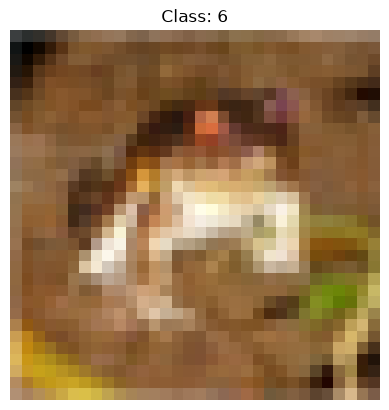

In [5]:
#look at one image:
plt.imshow(X_train[0])
plt.title(f"Class: {y_train[0][0]}")
plt.axis("off")
plt.show()

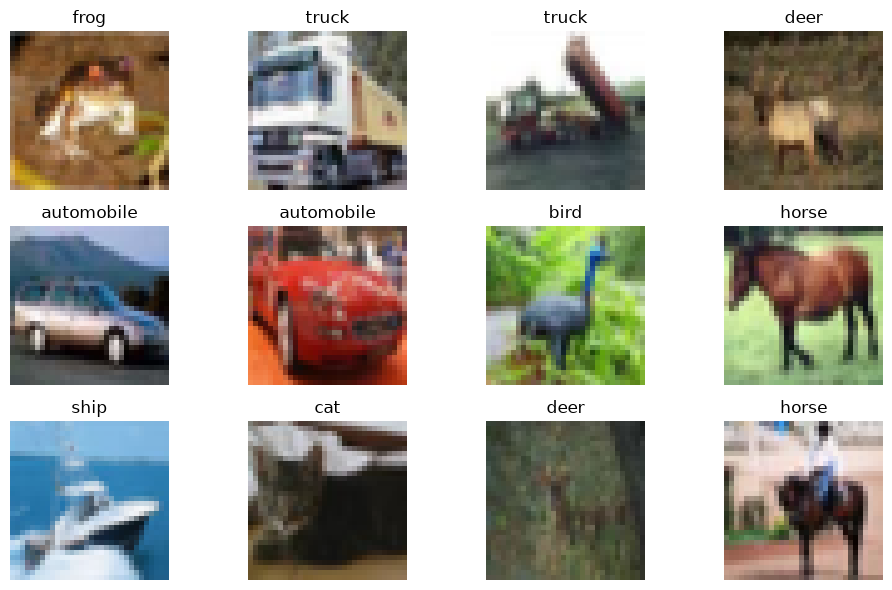

In [6]:
#This will show 12 images along with their actual class names instead of just numbers like 6.
#y_train[i] is still an array containing one value.

#class_names[6]
# "frog"
#So the flow is:

#y_train[i]       → [6]
#y_train[i][0]    → 6
#class_names[6]   → "frog"
#The 0 does not mean class zero. It means “take the first (and only) element of this array.”


class_names=["airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

plt.figure(figsize=(10,6))

for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.tight_layout()
plt.show()





The titles are the actual CIFAR-10 class labels converted from numbers into names.

In [7]:
#normalize the images
#float32 is a good explicit practice, not a CNN requirement.It is a good consistent practice, even though it isn't strictly required if the data is already floating-point.


X_train = X_train.astype("float32") /255.0
X_test=X_test.astype('float32')/255.0

#We normalized the pixel values of every image in both X_train and X_test.

In [8]:
print(X_train.min())
print(X_train.max())

0.0
1.0


After normalization:
0.0 to 1.0
So every pixel in every CIFAR-10 image is now scaled to the 0–1 range.

In [9]:
from tensorflow.keras import layers,models
model=models.Sequential([
    layers.Conv2D(32,(3,3),
                  activation='relu',
                  input_shape=(32,32,3),
                  ), 
                  layers.MaxPooling2D((2,2)),
                  layers.Conv2D(
                      64,
                      (3,3),
                      activation='relu'

                  ),
                  layers.MaxPooling2D((2,2)),
                  layers.Flatten(),
                  layers.Dense(64,activation='relu'),
                  layers.Dense(10,activation='softmax')
])


r:\C\PYTHON PROGRAMS\Deep Learning Proj 2 (CNN proj 1)\.venv-1\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


layers.Conv2D(32, (3,3), ...)
means:
32 → 32 filters
(3,3) → each filter has a 3×3 spatial size

Then:
layers.MaxPooling2D((2,2))
means the pooling window is 2×2.

MaxPooling2D((2,2)) means:
Take every 2×2 region of the feature map and replace it with one maximum value

It does not mean the final feature map becomes 2×2. Rather, every 2×2 region of the feature map is reduced to one maximum value, making the overall feature map smaller.(2,2) only tells us the pooling window size, not the final output size.

Then:
layers.Conv2D(64, (3,3), ...)

means the second convolutional layer learns 64 filters, each with a 3×3 spatial size.

Then we again apply:

layers.MaxPooling2D((2,2))

to reduce the spatial dimensions further.



We don't always write:

input_shape=(32,32,3)

That's specific to this CIFAR-10 dataset.

For example:

CIFAR-10 → (32,32,3)
MNIST     → (28,28,1)  if using CNN

The input shape must match the dataset's image shape.

Why Flatten()?

After the convolution and pooling layers, we have something like:

Feature maps
      ↓
3D structure
(height × width × channels)

For example, conceptually:

6 × 6 × 64

The Dense layer expects a 1D vector, not a 3D feature-map structure.

So:

layers.Flatten()

converts:

6 × 6 × 64

into:

2304 values

Then we can do:

Flatten
   ↓
Dense(64)
   ↓
Dense(10)

So the overall logic is:

Image
 ↓
Conv2D → extract features
 ↓
MaxPooling → reduce spatial size
 ↓
Conv2D → learn more complex features
 ↓
MaxPooling → reduce again
 ↓
Flatten → convert 3D feature representation into 1D
 ↓
Dense → classify

And that is why Flatten comes after the convolution/pooling part: we first want CNNs to extract spatial features, and only then hand those extracted features to the fully connected classifier.

PART 1: Feature extraction
Image
 ↓
Conv2D
 ↓
MaxPooling
 ↓
Conv2D
 ↓
MaxPooling

These layers extract visual features.

Then:

PART 2: Classification
 ↓
Flatten
 ↓
Dense(64)
 ↓
Dense(10)
Why Dense(64)?

After Flatten, we have a long vector of extracted features.

Dense(64) is a fully connected layer with 64 neurons. It takes those extracted features and learns combinations of them that are useful for deciding the class.

So:

CNN layers → "What features are present?"
Dense layers → "Based on these features, what class is this?"

Dense(10, activation="softmax")
because CIFAR-10 has 10 classes, so it produces 10 output probabilities.

Convolution + Pooling
        ↓
     Flatten
        ↓
   1D feature vector
        ↓
   Dense(64)
        ↓
   Dense(10)
        ↓
   10 probabilities

   The Dense(64) acts as a classifier layer that combines the extracted features before the final 10-class prediction.

   you will usually put a Dense layer after Flatten, but it does not have to be exactly Dense(64). The number of neurons is a design choice.

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

Each CIFAR-10 image is:
32 × 32 pixels
And because it is an RGB color image:
32 × 32 × 3

So 32 × 32 is the spatial dimension, and 3 represents the RGB channels.

and by default Keras uses padding="valid" and stride=1.

30 × 30 is the size of each feature map after the first convolution.

Your original image is:
32 × 32 × 3

You use a 3×3 filter, stride 1, and no padding:
(32 - 3) / 1 + 1 = 30

You defined 32 filters, each with a 3×3 spatial size. The output:

(30, 30, 32)

does not mean your filters became 30×30.

It means:

30 × 30 → size of EACH feature map
32     → number of feature maps

Why 30×30?

Your input image is:

32 × 32 × 3

A 3×3 filter moves across the image with stride 1 and no padding.

Horizontally, it can start at:

column 1
column 2
...
column 30

So there are 30 positions horizontally.

The same happens vertically → 30 positions vertically.

Therefore one 3×3 filter produces one 30×30 feature map.

Since you have 32 filters:

1 filter  → 30 × 30 feature map
32 filters → 30 × 30 × 32

Original image:
32 × 32 × 3

After applying a 3×3 filter with stride 1 and no padding, the filter can be placed only at 30 positions horizontally:

32 - 3 + 1 = 30

So the image still has 32 columns; the output feature map has 30 columns.

Think:

32 columns in input
↓
3 columns are occupied by filter
↓
30 possible starting positions

That's why the output is:

30 × 30 × 32

not because the original image had 30 columns.



one image gets all 32 filters.

Think of it like this:

One image
   ↓
Filter 1 → Feature map 1
Filter 2 → Feature map 2
Filter 3 → Feature map 3
...
Filter 32 → Feature map 32

So one image → 32 filters → 32 feature maps.

Then the same 32 filters are reused for image 2, image 3, ... all 50,000 images.

So 32 means 32 different pattern detectors, not 32 images.

The 896 parameters belong to the Conv2D layer, not to one image.

For one image:

32 filters
↓
each filter has 27 weights + 1 bias
↓
32 × 28 = 896 learnable parameters

But those same 896 parameters are reused for every image:

Image 1  → uses the same 896 parameters
Image 2  → uses the same 896 parameters
Image 3  → uses the same 896 parameters
...
Image 50,000 → uses the same 896 parameters

So don't think:

1 image = 896 parameters.

Think:

1 Conv2D layer = 896 learnable parameters, and those parameters are shared across all images.

That's called weight sharing, and it's a fundamental CNN concept.

The 896 parameters are shared across all images, and different filters (groups of those parameters) learn to detect different patterns, such as:

edges
textures
corners
shapes

So it's more accurate to say each filter learns a different feature, not each individual parameter.

The 32 feature maps remain 32 because pooling does not change the number of feature maps.

For each feature map:

30 × 30
   ↓ MaxPooling(2,2)
15 × 15

because each 2×2 region becomes one maximum value.

So:

30 × 30 × 32
        ↓
15 × 15 × 32

And parameters = 0 because MaxPooling has no learnable weights or biases. It simply selects the maximum value from each 2×2 region.

Now the second convolution + second pooling:
Second Conv2D

Input to 2nd Conv2D: 15 × 15 × 32
              ↓
64 filters
              ↓
Each filter → 13 × 13 feature map
              ↓
64 filters → 64 feature maps
              ↓
Output = 13 × 13 × 64

One image is passed through all 64 filters in that second convolutional layer.
The 18,496 comes from the parameters inside each of the 64 filters:

One filter:
3 × 3 × 32 = 288 weights
+ 1 bias
= 289 parameters

Then there are 64 filters:

289 × 64 = 18,496

So:

18,496 = parameters of the 64 filters together.
So 18,496 is the total learnable parameters of that layer, shared across all images.

You have:
13 × 13 × 64

That means 64 separate feature maps, each of size 13 × 13.

MaxPooling (2,2) is applied to each feature map separately:

13 × 13 → 6 × 6

So after pooling:

13 × 13 × 64
       ↓
6 × 6 × 64

Therefore:
Each of the 64 feature maps becomes 6 × 6. We do NOT end up with only one feature map.

filters are what create the feature maps.

For the second convolution:

64 filters
   ↓
64 feature maps

Then MaxPooling works on those 64 feature maps individually:

64 feature maps, each 13×13
        ↓ MaxPooling(2×2)
64 feature maps, each 6×6

So the 64 stays the same. Only the spatial size changes:

13 × 13 × 64
      ↓
6 × 6 × 64

6 × 6 = spatial dimensions of the feature map
64 = number of feature maps/channels produced by the second convolution

So total values are:

6 × 6 × 64 = 2304

Flatten simply takes this:

6 × 6 × 64

and converts it into:

2304

It doesn't calculate anything new. It just rearranges all those values into one long vector.
So:
Before Flatten:
6 × 6 × 64

After Flatten:
2304


The None represents the batch size.
For example, if you give the model 32 images at once:
(32, 6, 6, 64)
after Flatten:

(32, 2304)

Since the model doesn't have to know beforehand how many images you'll give it, Keras writes:
(None, 2304)

We have 64 neurons and each neuron receives 2304 inputs
Every one of the 64 neurons is connected to all 2304 values.
Each neuron multiplies the inputs by weights.
For one neuron:

x₁ × w₁
x₂ × w₂
x₃ × w₃
...
x₂₃₀₄ × w₂₃₀₄

Then it adds them:

x₁w₁ + x₂w₂ + ... + x₂₃₀₄w₂₃₀₄

Then adds its one bias:

x₁w₁ + x₂w₂ + ... + x₂₃₀₄w₂₃₀₄ + b

Then activation is applied.

2304 × 64 = 147,456 weights

147,456 + 64 biases
= 147,520 parameters

“Combination” means the neuron takes all 2304 inputs, multiplies each by its weight, and adds them together.

For example:

(input × weight) + (input × weight) + ... + bias
                         ↓
                    one output

So one neuron uses all 2304 inputs together to produce one output value.

64 neurons → 64 output values.

All 2304 inputs × their respective weights → added together → bias added → activation function → one output.
That output is the activation of one neuron.

One neuron takes the 2304 values, applies its learned weights, and produces one output. That output represents some learned pattern that helps the model classify the image.
For example, one neuron might respond strongly to some combination of edges, textures, shapes, etc. The network discovers these patterns automatically during training.

The Dense layers perform the final classification using the features extracted by the CNN.


The previous layer produces:

64 values

Those become the inputs to the final Dense layer:

64
 ↓
Dense(10)
 ↓
10 outputs

Because CIFAR-10 has 10 classes.

And again, every one of the 10 neurons receives all 64 inputs.

So the final layer has:

64 × 10 = 640 weights

plus:

10 biases

Therefore:

640 + 10 = 650 parameters
The 64 outputs go into the final Dense layer, where the network learns different combinations of those 64 values, and finally produces 10 outputs — one for each CIFAR-10 class.

if your final Dense layer uses Softmax. ✅
Then the 10 neurons each give one probability

In [11]:
# model compilation — where we define how the CNN should learn:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#Adam is an algorithm (optimizer) built into Keras/TensorFlow, not a separate tool.


In [12]:
#model.fit()
#This is where the actual learning/training starts.

history=model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.4600 - loss: 1.5035 - val_accuracy: 0.5708 - val_loss: 1.2334
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 23s 18ms/step - accuracy: 0.5966 - loss: 1.1502 - val_accuracy: 0.6159 - val_loss: 1.1067
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - accuracy: 0.6483 - loss: 1.0068 - val_accuracy: 0.6295 - val_loss: 1.0620
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - accuracy: 0.6811 - loss: 0.9197 - val_accuracy: 0.6532 - val_loss: 0.9982
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - accuracy: 0.7033 - loss: 0.8456 - val_accuracy: 0.6720 - val_loss: 0.9589
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - accuracy: 0.7281 - loss: 0.7851 - val_accuracy: 0.6707 - val_loss: 0.9721
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - accuracy: 0.7459 - loss: 0.7247 - val_accuracy: 0.6710 - val_loss: 0.9820
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 28s 22ms/step - accuracy: 0.7679 -

Look at the final epoch:

Training accuracy: 79.54%
Validation accuracy: 68.26%

And notice what happens after around Epoch 5:

Training accuracy:   keeps increasing
Validation accuracy: mostly stays around 67–68%

At the same time:

Training loss:       keeps decreasing
Validation loss:     starts increasing/fluctuating
What does this mean?

The model is getting better and better at the training images, but it isn't improving much on unseen validation images.

That's the basic sign of overfitting:

The model is learning the training data too specifically instead of learning patterns that generalize well.

batch_size=32 means the model takes 32 images at a time, calculates the loss, updates the weights, then takes the next 32 images.

In [13]:
test_loss,test_accuracy=model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6788 - loss: 0.9898


test_loss → how much error the model makes.
test_accuracy → percentage of test images classified correctly.

model.fit() does the training and calculates training/validation loss and accuracy each epoch.

history simply stores those results, so we can later access them:

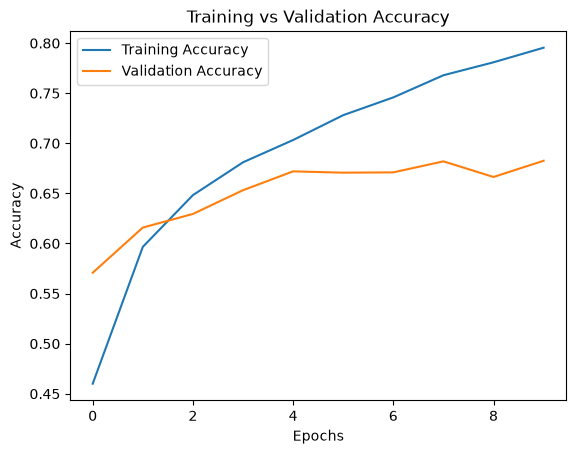

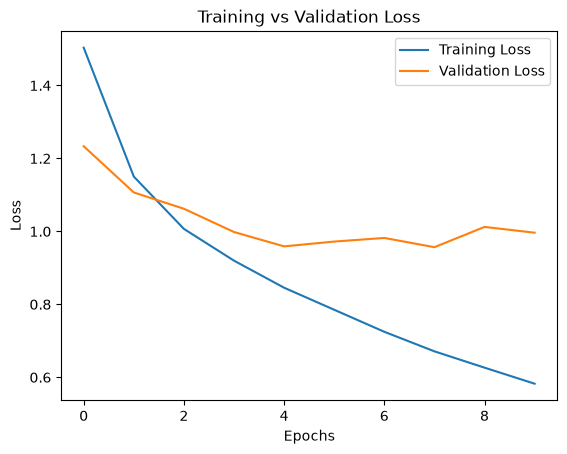

In [14]:
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()


plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

And they clearly show overfitting:

Accuracy: training keeps rising (~46% → 80%), while validation levels around ~67–68%.
Loss: training keeps falling, while validation loss starts rising/fluctuating after about epoch 5.

So your basic CNN is learning the training data increasingly well but not improving much on unseen data.

That is exactly what we wanted to observe before we add Dropout, Batch Normalization, and Early Stopping.

After each batch, weights are updated. After all batches finish → 1 epoch.
This repeats 10 times, and generally the model improves as it sees the training data repeatedly.

Technique	          Main purpose
Dropout	           Reduce overfitting

1. What is Dropout?
Suppose your Dense layer has 64 neurons:

64 neurons
● ● ● ● ● ● ● ● ● ● ...

Normally, during training, all 64 participate.
With dropout, we randomly turn off some neurons for that training step.
For example, with:

Dropout(0.5)

roughly 50% of the neurons are randomly dropped for each training step.

Conceptually:

Before dropout:

● ● ● ● ● ● ● ●
↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓

After dropout:


● ✕ ● ✕ ✕ ● ● ✕

The ✕ neurons do not participate in that particular training step.

2. Why would we deliberately turn neurons off?
Because we want to prevent the network from becoming too dependent on particular neurons.

Your current model is doing this:
"I can memorize very specific patterns in the training data."

That's why:
Training accuracy → ~80%
Validation accuracy → ~68%

The model is becoming too specialized to the training data.
Dropout forces the network to work with different combinations of neurons during training.

So instead of:
"I always depend on these particular neurons."

the network is encouraged to learn:
"I need to learn more robust patterns that work even when some neurons aren't available."

That helps reduce overfitting.

What does 0.5 actually mean?
Dropout(0.5)
means:
During training, randomly drop 50% of the neurons/activations for each training step.

Similarly:
Dropout(0.2)
means:
Drop about 20%.

It does not mean "remove those neurons permanently."
The neurons are randomly dropped temporarily during training.

Dropout is active during training, but not during testing/inference.
So:

TRAINING:
Random neurons turned off
        ↓
Model learns robust patterns


TESTING:
All neurons available
        ↓
Make prediction

You don't lose half of your model permanently.

Where will we put Dropout in our CNN?
Your current ending is approximately:

Flatten
   ↓
Dense(64)
   ↓
Dense(10)

We'll change it to:

Flatten
   ↓
Dense(64)
   ↓
Dropout(0.5)
   ↓
Dense(10)

So the dropout is applied after the Dense(64) layer and before the final classification layer.

Dropout(0.5) means roughly 50% of the 64 activations are randomly dropped during each training step. ✅ “50% of the 64 neuron activations are randomly dropped during training.”
We don't manually know which ones are dropped; they are chosen randomly each step. ✅
Then the remaining activations are passed to Dense(10). ✅

In [15]:
modell=models.Sequential([
    layers.Conv2D(
        32,(3,3),
        activation='relu',
        input_shape=(32,32,3)
    ),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(
        64,(3,3),
        activation='relu'
    ),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10,activation='softmax')


])

r:\C\PYTHON PROGRAMS\Deep Learning Proj 2 (CNN proj 1)\.venv-1\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
modell.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
history_drop=modell.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.3510 - loss: 1.7457 - val_accuracy: 0.4930 - val_loss: 1.4201
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.4745 - loss: 1.4522 - val_accuracy: 0.5521 - val_loss: 1.2833
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5229 - loss: 1.3293 - val_accuracy: 0.6060 - val_loss: 1.1285
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5527 - loss: 1.2568 - val_accuracy: 0.6184 - val_loss: 1.0861
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5712 - loss: 1.2004 - val_accuracy: 0.6238 - val_loss: 1.0793
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5915 - loss: 1.1466 - val_accuracy: 0.6443 - val_loss: 1.0165
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.6025 - loss: 1.1034 - val_accuracy: 0.6448 - val_loss: 1.0069
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.6213 - loss: 1.0698 -

CNN + Dropout:

Training accuracy ≈ 63.9%
Validation accuracy ≈ 65.2%

The important thing is that the gap became much smaller.
Why did training accuracy decrease? Because Dropout deliberately makes training harder by randomly dropping activations.

So Dropout is doing its job: reducing overfitting, even though the training accuracy itself becomes lower.

One more thing: your validation accuracy with Dropout hasn't become higher yet, so we shouldn't say Dropout made the model better overall. It made the model less overfitted.

but it's like at the very first time, it was 79% accuracy for the training. But now it dropped to 63. So, for solving overfitting, is that okay to like compromise with this?

Yes, to some extent. ✅
The goal is not to maximize training accuracy. The goal is to get good validation/test accuracy with a small gap from training accuracy.

In your case:
Before Dropout: 79.5% train vs 68.3% validation → large gap → overfitting.
After Dropout: 63.9% train vs 65.2% validation → very small gap → much less overfitting.

But 63.9% training accuracy is lower than we'd ideally want. So we don't simply accept the lower accuracy and stop.

We now try Batch Normalization and/or train longer, and see whether we can get:

higher validation accuracy + controlled overfitting.

We want a balance: high enough training accuracy, with a small train–validation gap.

In [20]:
#0.2 → drops only 20% → gives the model more capacity while still providing some regularization.

modelll=models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10,activation='softmax')
])

In [22]:
modelll.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']

)

history_drop2=modelll.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.4123 - loss: 1.6082 - val_accuracy: 0.5334 - val_loss: 1.3057
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.5426 - loss: 1.2786 - val_accuracy: 0.6081 - val_loss: 1.1434
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5958 - loss: 1.1407 - val_accuracy: 0.6307 - val_loss: 1.0509
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.6258 - loss: 1.0579 - val_accuracy: 0.6334 - val_loss: 1.0426
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.6505 - loss: 0.9907 - val_accuracy: 0.6686 - val_loss: 0.9604
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.6682 - loss: 0.9374 - val_accuracy: 0.6615 - val_loss: 0.9646
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.6846 - loss: 0.8891 - val_accuracy: 0.6705 - val_loss: 0.9428
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.6969 - loss: 0.8505 -

This is much better than Dropout(0.5). ✅
At the final epoch:

Training accuracy: 72.35%
Validation accuracy: 68.60%
Gap: only about 3.75%

So Dropout(0.2) is a better balance for our model: it reduced overfitting without hurting training accuracy as much as 0.5.
Also notice the validation loss is still decreasing overall, reaching 0.9023, which is a good sign.

0.2 gives the model more neurons to learn while still providing some protection against overfitting.

The goal is a good balance:
High enough training accuracy + small train/validation gap + high validation/test accuracy. ✅